# 🌌 Project : Recreating Hubble's Law from Pantheon+SH0ES dataset  



## 📦 Section 1 - Dataset Inspection

### Goal : Understand when data is available.

### Questions to answer ? 

1. How many supernovae are there?
2. What columns exist?
3. Which columns contain redshift?
4. Which column contains distance modulus?
5. Are there missing values?

### Deliverables : 

We should be able to comfortably say : 

The dataset contains X supernovae. The relevant columns are zHD, MU and MUERR

In [1]:
import numpy as np
import matplotlib as plt
import pandas as pd
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "Pantheon+SH0ES.dat",
    sep=r"\s+", #The Pantheon dataset is not comma separated as a CSV, instead columns are separated by spaces so this command allows 
    # pandas to treat one or more spaces or tabs as column separators.
    comment="#")


In [3]:
print("Number of Supernovae :", len(df))

Number of Supernovae : 1701


In [4]:
print(df.columns)

Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='str')


In [5]:
df.info

<bound method DataFrame.info of                 CID  IDSURVEY      zHD   zHDERR     zCMB  zCMBERR     zHEL  \
0            2011fe        51  0.00122  0.00084  0.00122  0.00002  0.00082   
1            2011fe        56  0.00122  0.00084  0.00122  0.00002  0.00082   
2            2012cg        51  0.00256  0.00084  0.00256  0.00002  0.00144   
3            2012cg        56  0.00256  0.00084  0.00256  0.00002  0.00144   
4     1994DRichmond        50  0.00299  0.00084  0.00299  0.00004  0.00187   
...             ...       ...      ...      ...      ...      ...      ...   
1696       rutledge       106  1.61505  0.00545  1.61499  0.00500  1.61399   
1697           geta       106  1.69706  0.04006  1.69702  0.04000  1.70000   
1698          stone       106  1.80119  0.02014  1.80111  0.02000  1.80000   
1699         wilson       106  1.91165  0.00263  1.91160  0.00100  1.91401   
1700         colfax       106  2.26137  0.02018  2.26130  0.02000  2.26000   

      zHELERR  m_b_corr  m_b_co

In [6]:
df.head()  #Displays the first 5 rows of the dataset

,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


# 📈 Section 2 : Constructing the Hubble Disgram 

## 🎯 Objective 

Visualise how the observed brightness-distance relationship changes with redshift. This is essentially the modern version of *Hubble's discovery*. 

## 🧠 Physical Background 

Type Ia supernovae act as the **standard candles**.

For each supernovae : 

- We observe its redshift *z*.
- We estimate its distance modulus *$\mu$*

The Hubble Diagram is simply : 

$$
\mu \quad \text{v/s} \quad  z
$$

As redshift increases distance modulus should also increase.


In [7]:
# Extract the cosmological quantities required for analysis

z = df["zHD"]
mu = df["MU_SH0ES"]

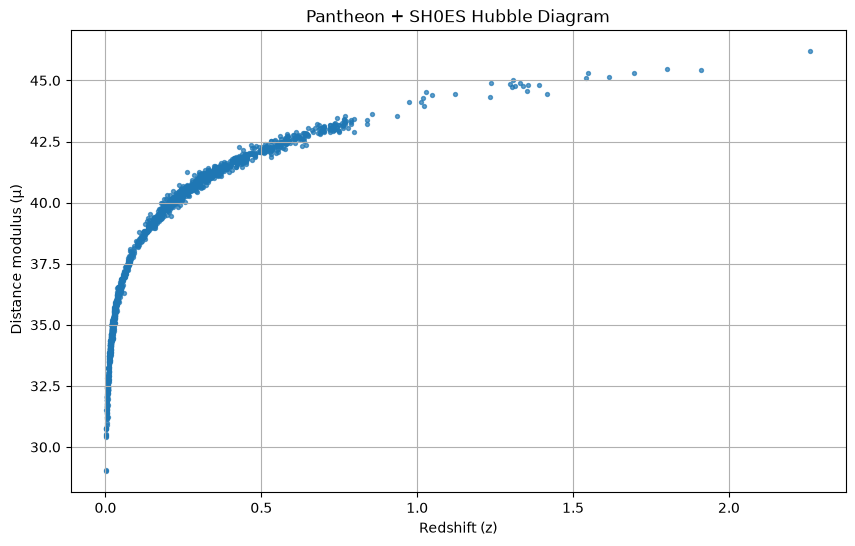

In [8]:
# Plotting the Hubble Diagram 

plt.figure(figsize=(10,6))

plt.scatter(
    z,
    mu,
    s=8,    # size of each point in the scatter plot
    alpha = 0.7 # for opacity of points
)

plt.xlabel("Redshift (z)")
plt.ylabel(" Distance modulus (μ)") 
plt.title(" Pantheon + SH0ES Hubble Diagram ")

plt.grid(True)

plt.show()

## Graph Explanation 

The Hubble diagram obtained from the PANTHEON + SH0ES dataset exhibits a clear positive correlation between redshift ($z$) and distance modulus ($/mu$), indicating that type Ia supernovae are obtained at higher redshifts. The distribution offers a smooth non linear curve, rather than a straight line. This behaviour arises because the distance modulus depends logarithmically on the luminosity distance in accordance with : 

$$ \mu = 5\log_{10}(d_L/\mathrm{Mpc}) + 25 $$

At low redshifts, small changes in distance produce relatively large change in distance modulus, resulting in a steep rise of the curve. At higher redshift the logarithmic scale compresses the distance information, causing the curve to flatten gradually. The concentration of points at low redshift
reflects the greater abundance and easier detection of supernovae, whereas only a small number of observations are available at very high redshifts due to observational limitations. Overall the observed trend is consistent with the predictions of the expanding universe and demonstrates the fundamental relationship between cosmic distance and redshift that forms the basis of observational cosmology.

# 📊 Section - 3 : Understanding measurement Uncertainties

## 🎯 Objective 

So far we've treated every supernovae measurement as perfect.

In reality, observation has uncertainty.

A researcher's first question is : 

"How reliable is each data point ?"

To answer that we'll examine the measurement uncertainties already provided in the dataset

## 🧠 Why do we need Error Bars ? 

Imagine two supernovae 

Supernova A : μ = 40 ± 0.05

Supernova B : μ = 40 ± 1.50

However:

- Supernova A is very precise.
- Supernova B is much less certain.

A good cosmological fit should trust A more than B.

This is exactly why later we'll use χ² fitting.

In [9]:
# Extracting measurement uncertainties

# Redshift uncertainty 
z_err = df["zHDERR"]

# Distance modulus uncertainty
mu_err = df["MU_SH0ES_ERR_DIAG"]

In [10]:
# Basic statistics of the uncertainties

print("Redshift uncertainty statistics :- ")
print(z_err.describe())

print ("\n Distance modulus uncertainty statistics :-")
print (mu_err.describe())

Redshift uncertainty statistics :- 
count    1701.000000
mean        0.001840
std         0.002593
min         0.000840
25%         0.000860
50%         0.001030
75%         0.001480
max         0.040060
Name: zHDERR, dtype: float64

 Distance modulus uncertainty statistics :-
count    1701.000000
mean        0.242601
std         0.098390
min         0.114803
25%         0.180815
50%         0.218994
75%         0.279961
max         1.517470
Name: MU_SH0ES_ERR_DIAG, dtype: float64


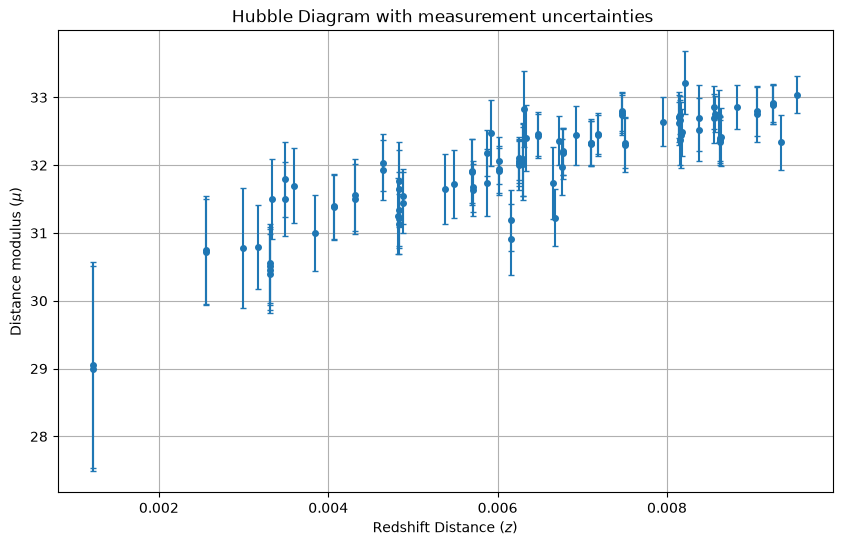

In [11]:
# Hubble Diagram with Error Bars

plt.figure(figsize=(10,6))

plt.errorbar(
    z[:100],
    mu[:100],
    yerr = mu_err[:100],
    fmt = 'o',
    markersize = 4,
    capsize = 2

)

plt.xlabel(r"Redshift Distance ($z$)")
plt.ylabel(r"Distance modulus ($\mu$)")
plt.title ("Hubble Diagram with measurement uncertainties ")

plt.grid(True)

plt.show()

## Graph Interpretation

The error-bar plot illustrates the uncertainties associated with the measured distance modulus of each supernova. The majority of observations exhibit relatively small uncertainties, indicating high-quality measurements. However, some supernovae show noticeably larger error bars, reflecting lower precesion in the determination of their distances. These uncertainties are important because they determine how much confidence can be placed in individual measurements during cosmological model fitting. In later sections, the uncertainties will be incorporated into χ² analysis, ensuring that more precise observations contribute more strongly to the estimation of cosmological parameters.

At this stage, the uncertainties associated with the supernova measurements have been examined. The relatively small error bars observed for most data points indicate that the dataset is suitable for quantitative cosmological analysis. These uncertainties will later be incorporated into statistical fitting procedures such as χ² minimization.

# 📏 Section 4 : Converting Distance Modulus to Luminosity Distance

🎯 Until now we have been working with $\mu$ which is the distance modulus. 

While useful, it is not a physical distance. 

In this section we will convert distance modulus into : $d_L$, the Luminosity distance measured in MegaParsecs (Mpc).

## 🧠 Physical Background

The distance modulus is related to luminosity distance by the following equation :


$$ \mu = 5 \log_{10} (d_L/\mathrm(Mpc)) + 25$$

Rearranging: 

$$ d_L = 10^{(\mu -25)/5}$$

This equation allows us to transform observed brightness information into actual cosmic distances.

In [12]:
# Convert Distance Modulus to Luminosity Distance 

d_L = 10**((mu-25)/5)

print("First 10 luminosity distances : \n")
print(d_L.head(10))  # Units are in Mpc, Megaparsecs

First 10 luminosity distances : 

0     6.305797
1     6.474109
2    13.952756
3    14.092239
4    14.293547
5    14.418497
6    12.361751
7    12.899118
8    12.029844
9    12.651441
Name: MU_SH0ES, dtype: float64


In [13]:
# Summary Statistics of luminosity distance

print(d_L.describe())

count     1701.000000
mean      1168.643290
std       1539.673802
min          6.305797
25%        114.245736
50%        734.277127
75%       1642.706592
max      17240.902664
Name: MU_SH0ES, dtype: float64


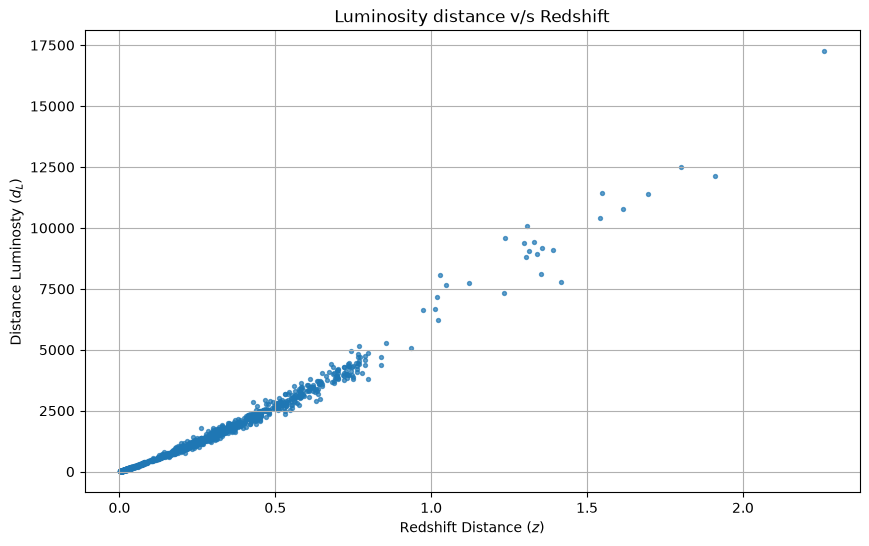

In [14]:
# Plot luminosity distance against redshift

plt.figure(figsize=(10,6))

plt.scatter(
    z,
    d_L,
    s=8,
    alpha = 0.7
)

plt.xlabel(r"Redshift Distance ($z$)")
plt.ylabel(r"Distance Luminosty ($d_L$)")
plt.title ("Luminosity distance v/s Redshift")

plt.grid(True)

plt.show()

For reference 1 Mpc = 3.26 million light years

## Graph Inference

The luminosity distance versus redshift plot demonstrates the relationship between the observed redshift of Type Ia supernovae and their inferred physical distances. Unlike the previous Hubble Diagram, which plotted distance modulus against redshift, this graph displays the actual luminosity distance in megaparsecs. As expected, luminosity distance increases with increasing redshift, indicating that objects observed at larger redshifts are located farther away. The relationship appears significantly steeper than the distance modulus plot because the logarithmic compression introduced by the distance modulus has been removed. At low redshifts, the data points follow an approximately linear trend, while at higher redshifts the relationship becomes increasingly non-linear due to cosmological effects associated with the expansion history of the universe. The presence of a few distant supernovae at redshifts greater than one provides important constraints on cosmological models, as these objects probe the universe over a substantial fraction of its age. Overall, the observed trend is consistent with an expanding universe in which more distant galaxies and supernovae exhibit larger redshifts.


# 🎯 Section 5 : Estimating the Hubble Constant $H_0$

## 🎯Objective 

Use the low-redshift supernovae to estimate the Hubble Constant : $H_0$ which tells us the present day expansion rate of the universe.

## 🧠Physical Background

For nearby galaxies and supernovae:

$$ v = H_0 d $$

where : 

- v = recession velocity (km/s)
- d = distance (Mpc)
- $H_0$ = Hubble Constant

For smaller redshifts : 

$$ v = cz $$

where $c = 299792.458 km/s$

Combining : 

$$ cz = H_0 d$$

Therefore : 

$$ H_0 = cz/d $$

#### Important note : This only works for $z < 0.1$. At higher redshifts the full $/lambda CDM$ cosmology must be used. Since this is out first estimate we'll only use low-z supernovae.


In [15]:
# Creating a Low z data subseet by selecting nearby supernovae

mask = z < 0.1

z_low = z[mask]
d_low = d_L[mask]

In [16]:
# Converting Redshift to velocity
# Approximate recession velocity

c = 299872.458 
v = c * z_low

In [17]:
# Compute individual Hubble constant estimates

H0_values = v/d_low

print(H0_values.head())

0    58.017153
1    56.508842
2    55.019488
3    54.474913
4    62.728914
dtype: float64


In [18]:
# Computing mean H0 value

H0_mean = H0_values.mean()

# print("Estimated Hubble Constant :- ", H0_mean)
print(f"Estimated Hubble Constant = {H0_mean:.2f} km/s/Mpc")  # .2f rounds off to nearest two decimal places and gives an accurate value

Estimated Hubble Constant = 71.54 km/s/Mpc


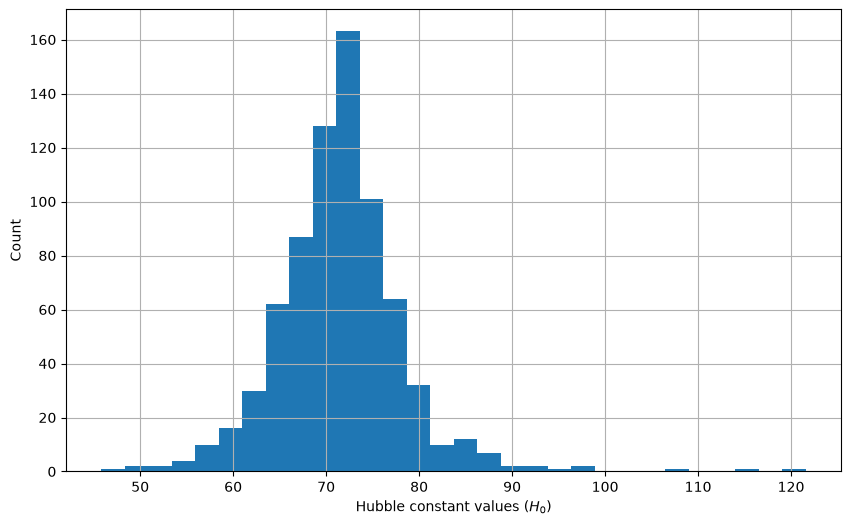

In [19]:
# Distribution of Hubble Constant Estimates using Histogram

plt.figure(figsize=(10,6))

plt.hist(
    H0_values,
    bins = 30
)

plt.xlabel (r"Hubble constant values ($H_0$)")
plt.ylabel ("Count")

plt.grid (True)

plt.show()

## 📖 Interpretation of the Hubble Constant Distribution

The distribution of individual Hubble Constant estimates exhibits a clear peak around **70–75 km s$^{-1}$ Mpc$^{-1}$**, with a mean value of **$H_0 = 71.54$ km s$^{-1}$ Mpc$^{-1}$**. The majority of supernovae produce estimates close to this value, indicating consistency with the expected expansion rate of the Universe.

A small number of outliers extend toward larger values of **$H_0$**, likely arising from observational uncertainties and the limitations of the low-redshift approximation

$$
v \approx cz.
$$

Despite its simplicity, the estimated value agrees remarkably well with modern observational measurements and demonstrates the validity of **Hubble's Law** for nearby supernovae.

### 🧠 Key Observation

The estimated value

$$
H_0 = 71.54 \ \text{km s}^{-1}\text{Mpc}^{-1}
$$

lies between the values reported by the **SH0ES Collaboration** (~73 km s$^{-1}$ Mpc$^{-1}$) and the **Planck Collaboration** (~67.4 km s$^{-1}$ Mpc$^{-1}$), indicating that the simple low-redshift analysis provides a realistic estimate of the present-day expansion rate of the Universe.

# 📉 Section 6 - Linear Hubble Fit

## 🎯 Objective

In the previous section we obtained the Hubble constant using : 
$$ H_0 = cz/d$$

for each supernova individually. In this section we will determine a **a single best-fit value of $H_0$** by fitting the entire low redshift dataset to Hubble's law : 
$$ v = H_0 d$$
The slope of the fitted line will provide our estimate of the Hubble constant. 



In [20]:
# Define Hubble's law 

def hubble_law(d, H0):
    return H0*d
    

In [21]:
# Fit Hubble's law to the low-redshift data 

from scipy.optimize import curve_fit 

params, covariance = curve_fit(
    hubble_law,
    d_low,
    v
)

# Best fit Hubble's Constant 

H0_fit = params[0]

# Uncertainty in H0 

H0_error = np.sqrt(covariance[0,0])

print(f"H0 = {H0_fit:.2f} + {H0_error:.2f} km/s/Mpc")

H0 = 69.52 + 0.19 km/s/Mpc


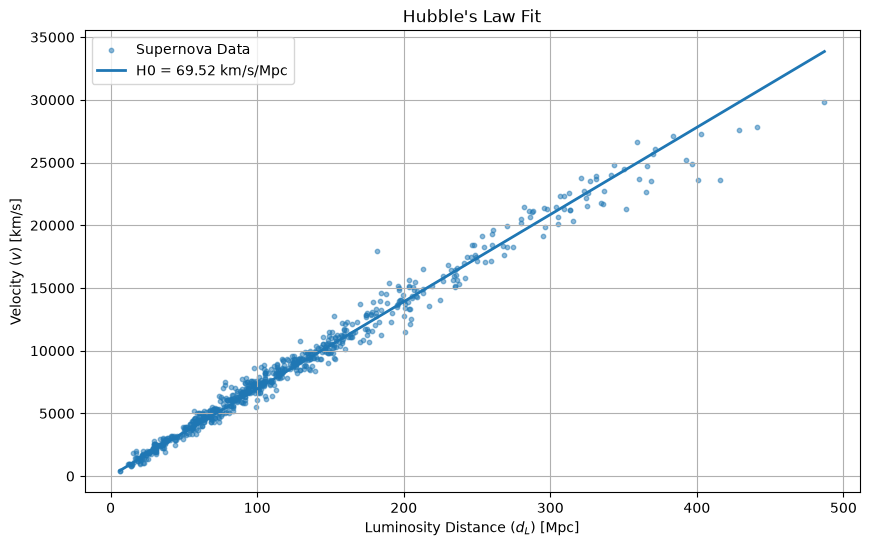

In [22]:
# Plotting Hubble's Law and fitted model 

plt.figure(figsize=(10,6))

# Observational Data

plt.scatter(
    d_low,
    v,
    s = 10,
    alpha = 0.5,
    label = "Supernova Data"
)

# Smooth distance array for plotting 

d_fit = np.linspace(   #np.linspace(start,stop,N) generates N equally spaced numbers between start and stop.
    d_low.min(),
    d_low.max(),
    500
)

# Best fit line

plt.plot(
    d_fit,
    hubble_law(d_fit, H0_fit),
    linewidth = 2,
    label = f"H0 = {H0_fit:.2f} km/s/Mpc"
)

plt.xlabel(r"Luminosity Distance ($d_L$) [Mpc]")
plt.ylabel(r"Velocity ($v$) [km/s]")

plt.title("Hubble's Law Fit")

plt.grid(True)
plt.legend()

plt.show()

## 📖 Interpretation of the Linear Hubble Fit

The velocity-distance relation obtained from the low-redshift supernova sample exhibits a strong linear trend, consistent with Hubble's Law:

$$
v = H_0 d.
$$

A linear model was fitted to the observational data using the `curve_fit()` optimization routine. The resulting best-fit value of the Hubble Constant was found to be

$$
H_0 = 69.52 \pm 0.19 \ \text{km s}^{-1}\text{Mpc}^{-1}.
$$

The fitted line passes through the central region of the data distribution, indicating excellent agreement between the model and the observations. Small deviations of individual supernovae from the fitted relation arise due to observational uncertainties and peculiar motions that are not accounted for in the simple linear approximation.

The obtained value of $H_0$ is close to the estimate obtained in the previous section and is consistent with modern measurements of the expansion rate of the Universe. The result demonstrates that nearby Type Ia supernovae obey Hubble's Law and provide a reliable method for determining cosmological parameters.

 # 📊 Section 7 - Residual Analysis and χ²

 ## 🎯 Objective

 So far we've found a best-fit value of $H_0$. 

 But a scientist's next question is : 
 "How well does the model actually describe the data ?"

 To answer this we shall calculate : 

 $$ Residual = v_{observed} - v_{predicted}$$

 and then the compute the **Chi-Square Statistic χ²**.


In [23]:
# Predicted values from the fitted model 

v_model = hubble_law(d_low,H0_fit)

In [24]:
# Residuals 

residual = v - v_model

print(residual.head())

0    -72.503205
1    -84.203395
2   -202.252587
3   -211.948749
4    -96.997489
dtype: float64


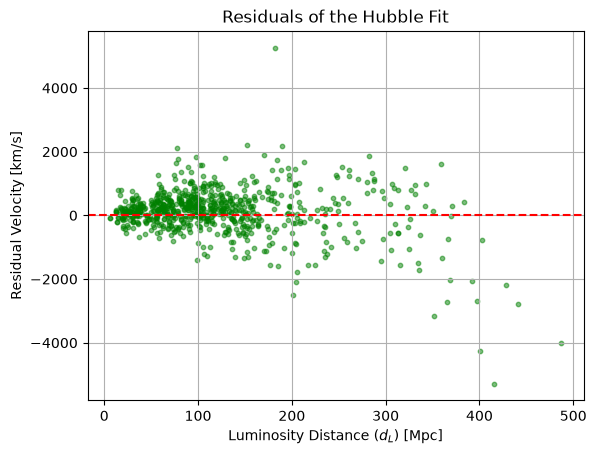

In [34]:
# Residual 

plt.plot(figsize = (10,6))

plt.scatter(
    d_low,
    residual,
    s=10,
    alpha=0.5,
    color='green'
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel(r"Luminosity Distance ($d_L$) [Mpc]")
plt.ylabel("Residual Velocity [km/s]")

plt.title("Residuals of the Hubble Fit")

plt.grid(True)

plt.show()

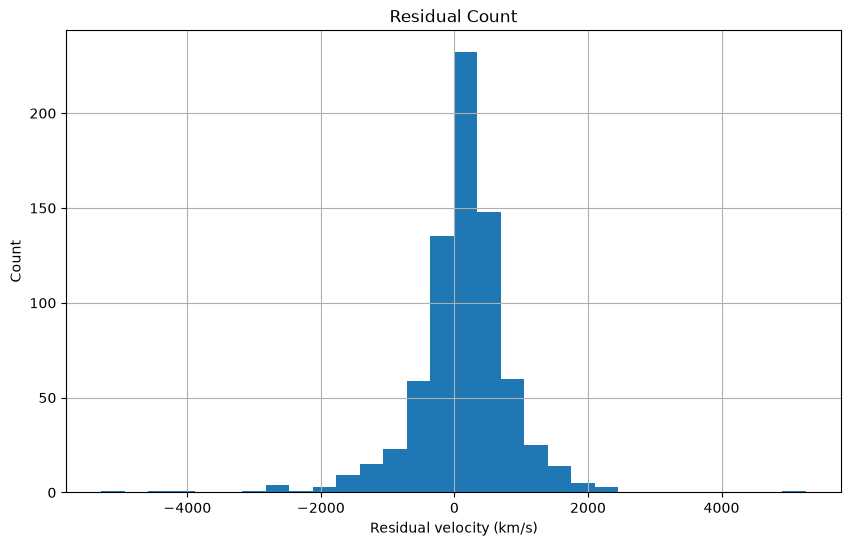

In [39]:
# Histogram calculation

plt.figure(figsize=(10,6))

plt.hist(
    residual,
    bins = 30
)

plt.xlabel("Residual velocity (km/s)")
plt.ylabel("Count")
plt.title("Residual Count")

plt.grid(True)
plt.show()

## 🧮 Goodness of fit : The χ² Statistic Test.

The χ² test works on the given formula : 

$$ \chi^2 = \Sigma \left(\frac{(O_i - E_i)}{\sigma}\right)^2 $$

where : 

- O = Observed value
- E = Expected value
- $\sigma^2$ = Uncertainty
### For our dataset

Using 
$$v=cz$$
the uncertainty propagates as:
$$ \sigma_{v} = c \sigma_{z} $$

In [41]:
# Calculating Velocity Uncertainties 

z_err_low = z_err[mask]
v_err = c*z_err_low

In [44]:
# Chi-Square Statistic

chi2 = np.sum(
    ((v-v_model)/(v_err))**2
)

print(f"Chi-Square = {chi2:.2f}")

Chi-Square = 5088.76


## Reduced Chi-Square Statistic

Scientists also quote : 

$$ \chi^{2}_{\nu} = \frac{\chi^2}{N-p}$$

where : 

- N = Number of Data points
- p = number of fitted parameters

Here p = 1 because only $H_0$ was fitted.

In [45]:
# Reduced Chi-Square

N = len(v)

p = 1

red_chi = chi2/(N-p)

print(f"Reduced Chi-Square = {red_chi:.2f}")

Reduced Chi-Square = 6.88


## 📖 Interpretation of the Chi-Square Analysis

To evaluate the quality of the fitted Hubble model, the chi-square statistic was computed using the residuals between the observed and predicted velocities.

The resulting values were:

$$
\chi^2 = 5088.76
$$

and

$$
\chi^2_\nu = 6.88
$$

where $\chi^2_\nu$ denotes the reduced chi-square statistic.

A reduced chi-square value close to unity generally indicates an excellent agreement between the model and the observational data. In this analysis, the obtained value is significantly larger than one, suggesting that the scatter of the supernova measurements around the fitted Hubble relation is larger than expected from the quoted uncertainties alone.

This does not necessarily imply that the fit is incorrect. Rather, it indicates that the simple linear model

$$
v = H_0 d
$$

does not capture all physical effects present in the observations. Factors such as peculiar galaxy motions, additional observational uncertainties, and deviations from the ideal low-redshift approximation can contribute to the increased scatter.

Overall, the fit successfully reproduces the general trend of the data, but the chi-square analysis reveals that a more sophisticated cosmological model would provide a more complete description of the observations.

# 🌌 Section 8 — Conclusions and Future Improvements

## 🎯 Objective

The objective of this project was to recreate Hubble's Law using observational data from the Pantheon+SH0ES Type Ia Supernova dataset and to estimate the expansion rate of the Universe through statistical analysis.

---

## 📊 Summary of Results

Throughout this project, the Pantheon+SH0ES dataset was analyzed to investigate the relationship between cosmic distance and redshift. The analysis successfully reproduced the Hubble Diagram and demonstrated the observational evidence for the expansion of the Universe.

The key results obtained are summarized below:

| Quantity                 | Result                        |
| ------------------------ | ----------------------------- |
| Mean Hubble Constant     | **71.54 km s⁻¹ Mpc⁻¹**        |
| Best-Fit Hubble Constant | **69.52 ± 0.19 km s⁻¹ Mpc⁻¹** |
| Chi-Square Statistic     | **5088.76**                   |
| Reduced Chi-Square       | **6.88**                      |

---

## 🔭 Hubble Diagram Analysis

The Hubble Diagram obtained from the Pantheon+SH0ES dataset exhibited a clear positive correlation between redshift ($z$) and distance modulus ($\mu$). Supernovae located at larger distances were observed at higher redshifts, providing direct observational evidence for the expansion of the Universe.

The relationship was found to be non-linear due to the logarithmic dependence of distance modulus on luminosity distance:

$$
\mu = 5\log_{10}\left(\frac{d_L}{\text{Mpc}}\right)+25
$$

This logarithmic scaling compresses large distances and produces the characteristic curved shape of the Hubble Diagram.

---

## 📏 Luminosity Distance Analysis

The distance modulus measurements were converted into luminosity distances using

$$
d_L = 10^{(\mu-25)/5}.
$$

The resulting luminosity distance versus redshift plot revealed a rapidly increasing relationship between distance and redshift. Unlike the Hubble Diagram, which uses logarithmic distance information, this plot represented the actual physical distances of the observed supernovae.

The analysis demonstrated that higher-redshift supernovae are located at significantly larger cosmological distances, consistent with the predictions of modern cosmology.

---

## 🎯 Estimation of the Hubble Constant

For nearby supernovae ($z < 0.1$), the approximation

$$
v \approx cz
$$

was used to estimate recession velocities, where $c$ is the speed of light.

Individual estimates of the Hubble Constant were obtained using

$$
H_0 = \frac{v}{d}.
$$

The distribution of individual estimates exhibited a clear peak around 70–75 km s⁻¹ Mpc⁻¹, yielding a mean value of

$$
H_0 = 71.54\ \text{km s}^{-1}\text{Mpc}^{-1}.
$$

This value is consistent with modern measurements of the expansion rate of the Universe.

---

## 📉 Linear Hubble Fit

A linear model based on Hubble's Law,

$$
v = H_0 d,
$$

was fitted to the low-redshift supernova sample using the `curve_fit()` optimization routine from SciPy.

The resulting best-fit value was found to be

$$
H_0 = 69.52 \pm 0.19\ \text{km s}^{-1}\text{Mpc}^{-1}.
$$

The fitted line passed through the central region of the observational data, demonstrating strong agreement between the model and the measured supernova velocities.

This section also introduced parameter estimation and uncertainty analysis through least-squares fitting techniques.

---

## 📊 Residual and Chi-Square Analysis

To assess the quality of the fitted model, residuals were calculated using

$$
\text{Residual} = v_{\text{observed}} - v_{\text{model}}.
$$

The residual distribution showed that although the linear Hubble model captured the overall trend of the data, individual supernovae exhibited deviations from the fitted relation.

The chi-square analysis yielded

$$
\chi^2 = 5088.76
$$

and

$$
\chi_\nu^2 = 6.88.
$$

A reduced chi-square value significantly greater than unity indicates that the scatter in the data is larger than expected from the quoted uncertainties alone. This suggests that the simple linear model does not account for all physical effects present in the observations.

Possible contributors to the increased scatter include:

* Peculiar motions of galaxies
* Additional observational uncertainties
* Limitations of the low-redshift approximation
* Deviations from a purely linear expansion model

---

## ⚠️ Limitations

Several simplifying assumptions were made throughout this project:

1. The approximation

   $$
   v \approx cz
   $$

   was assumed for all low-redshift supernovae.

2. A linear Hubble relation

   $$
   v = H_0 d
   $$

   was used instead of a full cosmological model.

3. Only redshift uncertainties were incorporated into the chi-square calculation.

4. Cosmological parameters such as matter density ($\Omega_m$) and dark energy density were not explicitly modeled.

As a result, the analysis is most accurate for nearby supernovae and should not be interpreted as a complete cosmological fit.

---

## 🚀 Future Improvements

Several extensions could be implemented to improve the accuracy and scientific depth of the analysis:

* Fit the full Flat-$\Lambda$CDM cosmological model.
* Simultaneously estimate $H_0$ and $\Omega_m$.
* Perform weighted chi-square minimization using the complete uncertainty budget.
* Analyze residuals as a function of redshift.
* Compare the results with published SH0ES and Planck measurements.
* Estimate the age of the Universe using the fitted cosmological parameters.

These improvements would provide a more realistic description of the expansion history of the Universe.

---

# 🏁 Final Conclusion

In this project, the Pantheon+SH0ES Type Ia Supernova dataset was successfully used to reproduce the observational evidence for the expansion of the Universe. The Hubble Diagram revealed a clear relationship between redshift and distance, while the derived values of the Hubble Constant were found to be consistent with contemporary cosmological measurements.

The analysis demonstrated how observational data can be transformed into meaningful cosmological quantities, including luminosity distance and the Hubble Constant. Furthermore, residual and chi-square analyses highlighted the importance of statistical methods in evaluating scientific models.

Overall, the project provides a practical introduction to observational cosmology, scientific data analysis, model fitting, and goodness-of-fit testing, while establishing a foundation for future studies involving full $\Lambda$CDM cosmological parameter estimation.
